# Module 07 — Cell Type Annotation (v4)

This notebook visualizes cell type annotation results from
`scripts/07_annotation.py`. After scANVI integration (Module 05) and Leiden
clustering (Module 06), de novo annotation is performed using IVD-specific
marker gene signatures, with CellTypist validation for non-mesenchymal subtypes.

**Pipeline version:** v4 (scANVI-based, 12 modules)

**Annotation summary:**
- **NP:** 10 cell types (NP_mature_chondrocyte, NP_fibrocartilaginous, NP_notochordal,
  Fibrochondrocyte_chondroid, Fibrochondrocyte_fibroid, Fibrochondrocyte_stressed,
  NP_stressed, Macrophage_M2, Pericyte_SMC, unassigned)
- **AF:** 2 cell types (AF_inner, AF_outer)
- **CEP:** 3 cell types (EP_hyaline, Fibroblast_like, Fibrochondrocyte_chondroid)
- **all_cells:** 19 cell types across all compartments

**Data sources:**
- `data/integrated/{NP,AF,CEP,all_cells}.h5ad` — Annotated objects with `cell_type` in `.obs`
- `results/integration/cell_type_definitions.tsv` — Cell type marker definitions
- `results/integration/annotation_dotplots/` — Marker expression dot plots
- `results/integration/cluster_markers/` — Cluster-level marker gene tables
- `results/integration/celltypist_validation/` — CellTypist concordance tables

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
RESULTS_DIR = BASE / 'results' / 'integration'
DOTPLOT_DIR = RESULTS_DIR / 'annotation_dotplots'
MARKER_DIR = RESULTS_DIR / 'cluster_markers'
CELLTYPIST_DIR = RESULTS_DIR / 'celltypist_validation'

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')

  NP: found
  AF: found
  CEP: found


## Cell Type Definitions

The table below shows all annotated cell types with their defining markers,
cluster assignments, and confidence distributions.

In [2]:
# Load and display cell type definitions
ct_def_path = RESULTS_DIR / 'cell_type_definitions.tsv'
if ct_def_path.exists():
    ct_defs = pd.read_csv(ct_def_path, sep='\t')
    display(ct_defs.style.set_caption('Cell Type Definitions — All Compartments'))
else:
    print('Cell type definitions file not found')

,object,cell_type,coarse_cell_type,n_cells,clusters,canonical_markers,confidence_distribution
0,NP,Fibrochondrocyte_chondroid,Fibrochondrocyte_like,18354,"M23,M44,M45,M5","COL2A1,ACAN,SOX9",high=16236; medium=2118; low=0
1,NP,Fibrochondrocyte_fibroid,Fibrochondrocyte_like,3648,M30,"COL1A1,COL1A2,DCN",low=3648; high=0; medium=0
2,NP,Fibrochondrocyte_stressed,Fibrochondrocyte_like,4195,M25,"MMP13,ADAMTS5,VEGFA",low=4195; high=0; medium=0
3,NP,Macrophage_M2,Macrophage,325,NM4,"CD163,MRC1,MSR1,TGFB1",high=325; low=0; medium=0
4,NP,NP_fibrocartilaginous,Fibroblast_like,90857,"M15,M2,M24,M26,M27,M29,M3,M32,M34,M35,M37,M38,M39,M42,M43,M47,M48,M50,M51,M55,M6,M8","COL1A1,COL2A1,VCAN",high=90857; low=0; medium=0
5,NP,NP_mature_chondrocyte,Chondrocyte_like,115388,"M0,M1,M11,M12,M13,M14,M16,M17,M18,M19,M20,M21,M22,M28,M4,M40,M41,M46,M49,M9","ACAN,COL2A1,SOX9,COMP,PRG4",high=113054; medium=2334; low=0
6,NP,NP_notochordal,Chondrocyte_like,8920,"M10,M52,M53,M54","T,SHH,NOG,CD24,KRT8,KRT18,KRT19",high=7670; medium=1250; low=0
7,NP,NP_stressed,Chondrocyte_like,3613,M31,"MMP13,ADAMTS5,IL1B,TNF,VEGFA,HIF1A",high=3613; low=0; medium=0
8,NP,Pericyte_SMC,Pericyte_SMC,60,NM5,"ACTA2,RGS5,PDGFRB",high=60; low=0; medium=0
9,NP,unassigned,unassigned,17607,"NM0,NM1,NM2,NM3,M33,M36,M7",nan,low=17607; high=0; medium=0


## Annotated UMAPs per Compartment

UMAP colored by final `cell_type` annotation for each compartment.

### NP — Annotated UMAP

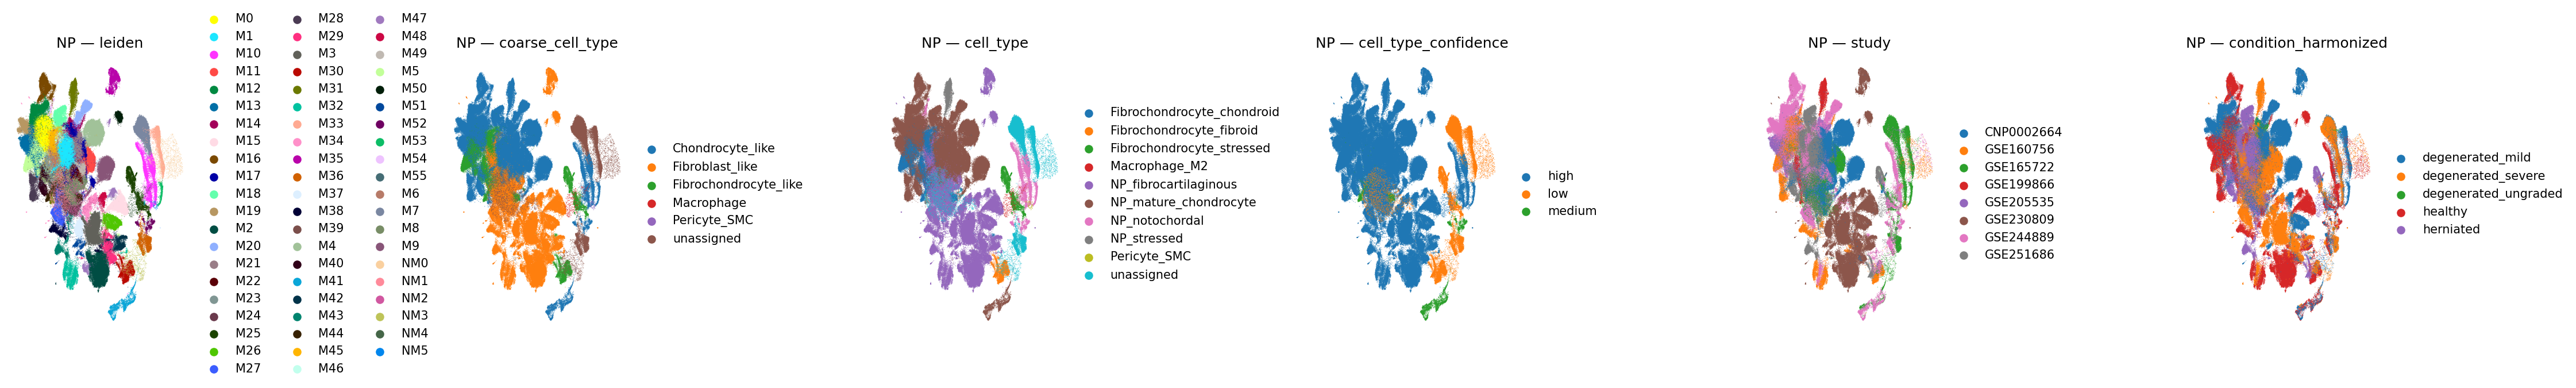

### AF — Annotated UMAP

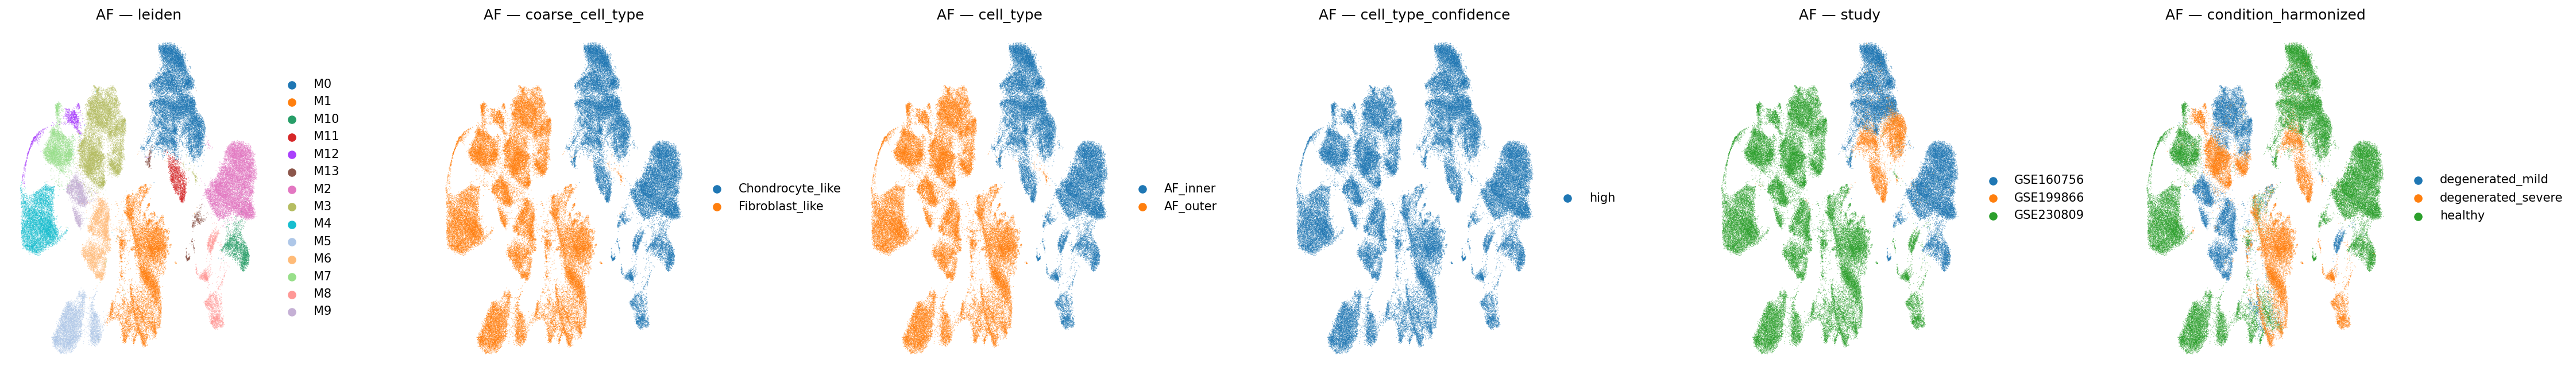

### CEP — Annotated UMAP

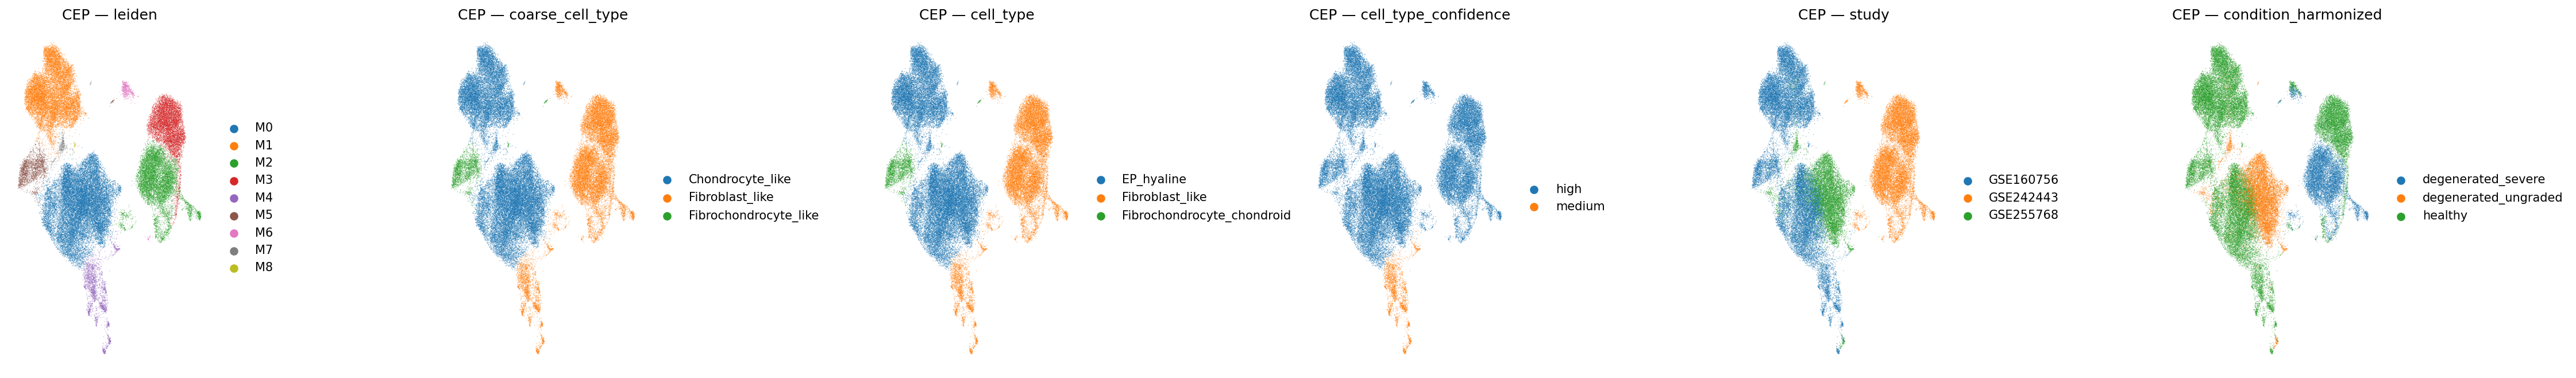

### all_cells — Annotated UMAP

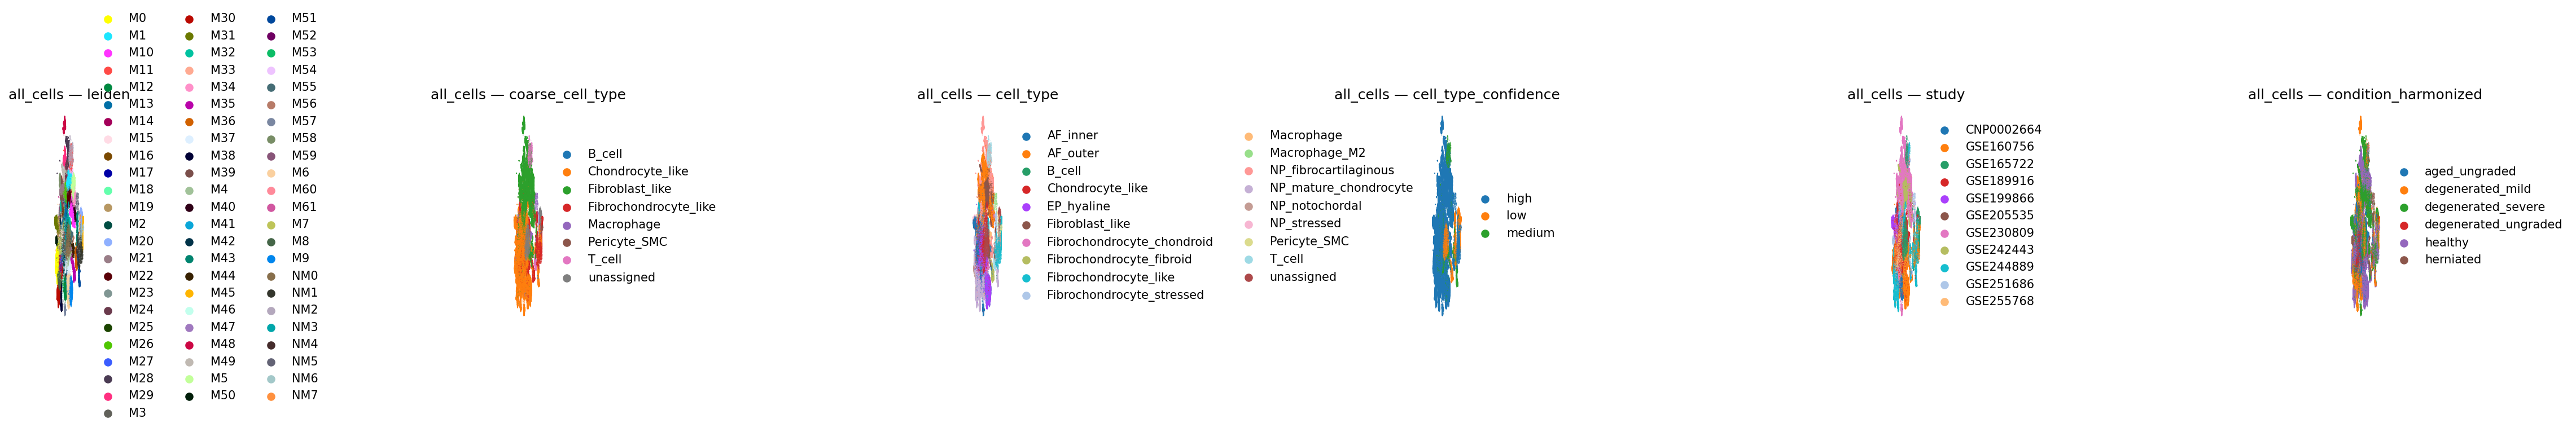

In [3]:
# Display pre-generated annotated UMAP images
for comp in ['NP', 'AF', 'CEP', 'all_cells']:
    umap_path = RESULTS_DIR / f'umap_{comp}_annotated.png'
    if umap_path.exists():
        display(Markdown(f'### {comp} — Annotated UMAP'))
        display(Image(filename=str(umap_path), width=800))
    else:
        # Fallback: basic UMAP plot
        umap_basic = RESULTS_DIR / f'umap_{comp}.png'
        if umap_basic.exists():
            display(Markdown(f'### {comp} — UMAP'))
            display(Image(filename=str(umap_basic), width=800))
        else:
            print(f'No UMAP image for {comp}')

## Marker Expression Dot Plots

Dot plots show expression of canonical markers per cell type. Dot size
represents fraction of cells expressing the gene; color intensity represents
mean expression level.

Annotation dot plots: 12 PDF files
  AF_all_markers_canonical_markers.pdf
  AF_mesenchymal_canonical_markers.pdf
  AF_mesenchymal_coarse_canonical_markers.pdf
  CEP_all_markers_canonical_markers.pdf
  CEP_mesenchymal_canonical_markers.pdf
  CEP_mesenchymal_coarse_canonical_markers.pdf
  NP_all_markers_canonical_markers.pdf
  NP_mesenchymal_canonical_markers.pdf
  NP_mesenchymal_coarse_canonical_markers.pdf
  NP_non_mesenchymal_canonical_markers.pdf
  NP_non_mesenchymal_coarse_canonical_markers.pdf
  all_cells_unassigned_canonical_markers.pdf

Generating marker dot plots from integrated objects...


### NP — Canonical Marker Expression

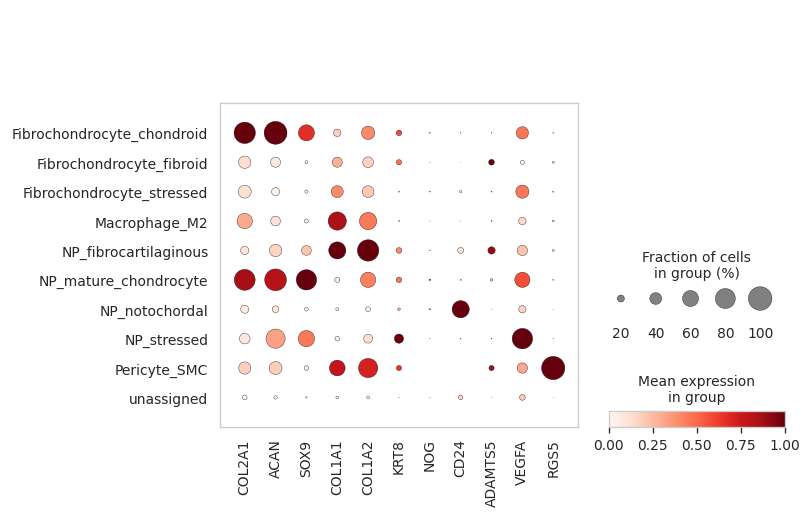

### AF — Canonical Marker Expression

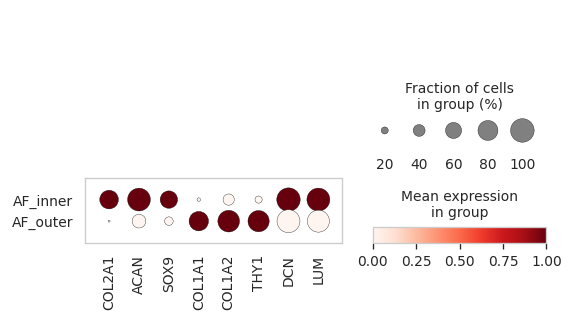

### CEP — Canonical Marker Expression

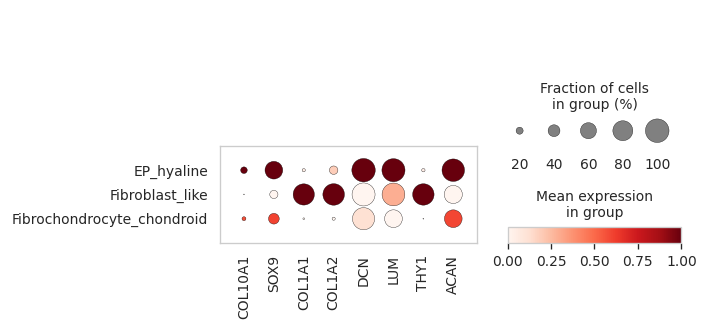

In [4]:
# List available annotation dot plots
dotplot_files = sorted(DOTPLOT_DIR.glob('*.pdf'))
print(f'Annotation dot plots: {len(dotplot_files)} PDF files')
for f in dotplot_files:
    print(f'  {f.name}')

# Note: PDF dot plots cannot be embedded directly in notebooks.
# They are available in results/integration/annotation_dotplots/ for review.
# Instead, show marker expression from the integrated objects directly.

print('\nGenerating marker dot plots from integrated objects...')

MARKERS_PER_COMP = {
    'NP': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'KRT19', 'KRT8',
           'T', 'SHH', 'NOG', 'CD24', 'MMP13', 'ADAMTS5', 'VEGFA',
           'CD163', 'ACTA2', 'RGS5', 'PTPRC'],
    'AF': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM'],
    'CEP': ['COL2A1', 'COL10A1', 'SOX9', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'THY1', 'ACAN'],
}

for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    markers = MARKERS_PER_COMP.get(comp_name, [])
    if not markers:
        continue

    adata = sc.read_h5ad(comp_path)
    if 'cell_type' not in adata.obs.columns:
        del adata
        continue

    available = [g for g in markers if g in adata.var_names]
    if not available:
        del adata
        continue

    display(Markdown(f'### {comp_name} — Canonical Marker Expression'))
    sc.pl.dotplot(adata, var_names=available, groupby='cell_type',
                  standard_scale='var', show=True)
    del adata

## Annotation Confidence

Distribution of annotation confidence levels (high/medium/low) across cell
types, showing how confidently each cell type was assigned.

In [5]:
# Load annotation confidence from integrated objects
for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'cell_type' not in obs_df.columns:
        continue

    display(Markdown(f'### {comp_name} — Cell Type Summary'))

    # Cell type counts
    ct_counts = obs_df['cell_type'].value_counts()
    print(f'{comp_name}: {len(obs_df):,} cells, {ct_counts.shape[0]} cell types')
    print(ct_counts.to_string())
    print()

    # Confidence distribution if available
    if 'cell_type_confidence' in obs_df.columns:
        conf_ct = pd.crosstab(obs_df['cell_type'], obs_df['cell_type_confidence'])
        display(conf_ct.style.set_caption(f'{comp_name} — Confidence per Cell Type'))

    del obs_df

### NP — Cell Type Summary

NP: 262,967 cells, 10 cell types
cell_type
NP_mature_chondrocyte         115388
NP_fibrocartilaginous          90857
Fibrochondrocyte_chondroid     18354
unassigned                     17607
NP_notochordal                  8920
Fibrochondrocyte_stressed       4195
Fibrochondrocyte_fibroid        3648
NP_stressed                     3613
Macrophage_M2                    325
Pericyte_SMC                      60



cell_type_confidence,high,low,medium
cell_type,,,
Fibrochondrocyte_chondroid,16236,0,2118
Fibrochondrocyte_fibroid,0,3648,0
Fibrochondrocyte_stressed,0,4195,0
Macrophage_M2,325,0,0
NP_fibrocartilaginous,90857,0,0
NP_mature_chondrocyte,113054,0,2334
NP_notochordal,7670,0,1250
NP_stressed,3613,0,0
Pericyte_SMC,60,0,0


### AF — Cell Type Summary

AF: 84,568 cells, 2 cell types
cell_type
AF_outer    49651
AF_inner    34917



cell_type_confidence,high
cell_type,
AF_inner,34917
AF_outer,49651


### CEP — Cell Type Summary

CEP: 50,769 cells, 3 cell types
cell_type
EP_hyaline                    31775
Fibroblast_like               17038
Fibrochondrocyte_chondroid     1956



cell_type_confidence,high,medium
cell_type,,
EP_hyaline,31775,0
Fibroblast_like,14932,2106
Fibrochondrocyte_chondroid,1956,0


## CellTypist Validation

CellTypist concordance tables comparing de novo annotations with automated
predictions for non-mesenchymal cell types.

In [6]:
# Load CellTypist concordance tables
concordance_files = sorted(CELLTYPIST_DIR.glob('*_concordance.tsv'))

if concordance_files:
    for f in concordance_files:
        comp = f.stem.replace('_concordance', '')
        df = pd.read_csv(f, sep='\t')
        display(Markdown(f'### {comp} CellTypist Concordance'))
        display(df)

        # Summary: fraction concordant
        n_concordant = df['concordant'].sum() if 'concordant' in df.columns else 0
        n_total = len(df)
        print(f'  Concordant clusters: {n_concordant}/{n_total} '
              f'({n_concordant/n_total*100:.0f}%)')
else:
    print('No CellTypist concordance files found')

### NP CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,917,unassigned,Endothelial cells,100.0,False
1,1,859,unassigned,Classical monocytes,100.0,False
2,2,638,unassigned,Classical monocytes,100.0,False
3,3,610,unassigned,CD16+ NK cells,37.0,False
4,4,325,Macrophage_M2,Macrophages,85.5,True
5,5,60,Pericyte_SMC,Fibroblasts,96.7,False


  Concordant clusters: 1/6 (17%)


## Status — Module 07 Complete (v4)

### Summary
- De novo cell type annotation using IVD-specific marker gene signatures
- CellTypist validation for non-mesenchymal subtypes (Immune_All_Low model)
- NP: 10 cell types, AF: 2 cell types, CEP: 3 cell types, all_cells: 19 cell types
- Annotation confidence tracked via `cell_type_confidence` column
- Results stored in `cell_type` column of integrated objects

### Next steps
- Module 08: Pseudobulk differential expression analysis (healthy vs degenerated)
- Module 09: Biological interpretation (pathway enrichment, TF activity)
- Module 10: Trajectory/pseudotime analysis
- Module 11: Cell-cell communication